In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../data/transactions_clean.csv")
df.head()

,date,description,amount,payment_mode,category
0,2026-05-06,DMART *2125,2801,NetBanking,Shopping
1,2026-07-27,PVR CINEMAS *2582,137,UPI,Entertainment
2,2026-01-05,AIRTEL BROADBAND *2893,1615,NetBanking,Bills
3,2026-05-19,FLIPKART *5080,1625,UPI,Shopping
4,2026-06-21,ZOMATO *7056,449,UPI,Food


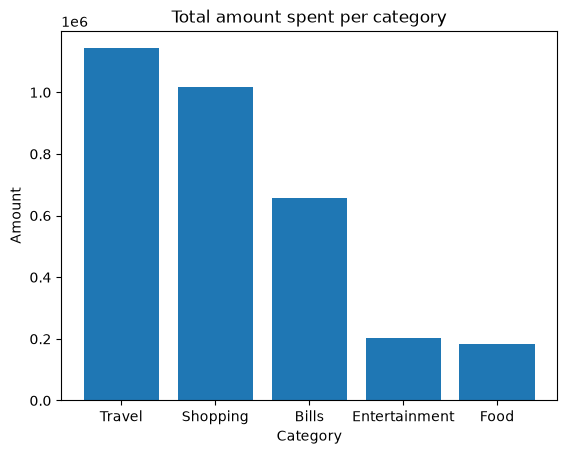

In [4]:
category_total = df.groupby("category")["amount"].sum().sort_values(ascending=False)
plt.bar(category_total.index, category_total.values)
plt.title("Total amount spent per category")
plt.xlabel("Category")  
plt.ylabel("Amount")
plt.show()  


whats new line by line 
fig is the paper and ax is the charts Drawn on the paper
figsize is the Height and the Width of the cahsrts taht We need 
labels are used for wirting the hedaing in the lebels
If someone asks "What did you learn from making charts?", you can say:

"I learned that charts can mislead. My monthly chart showed a big drop in September, but that was because the data only covered 24 days. So I started the y-axis at zero and labeled the partial month."

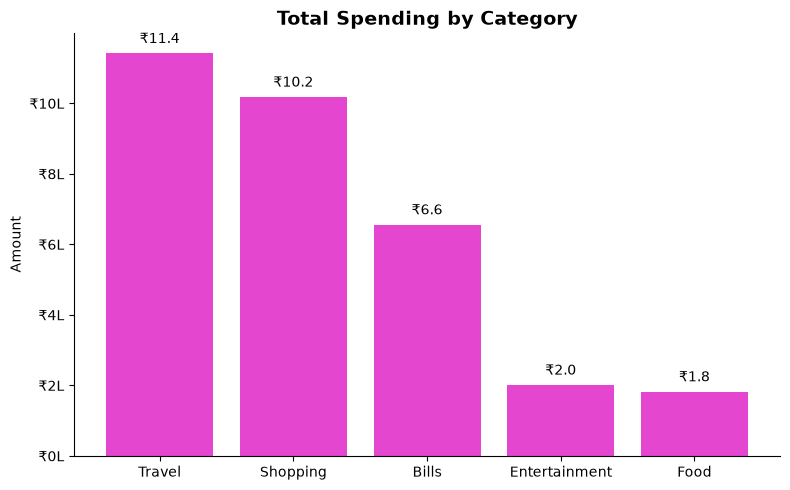

In [9]:
fig, ax = plt.subplots(figsize=(8 , 5))
bars = ax.bar(category_total.index, category_total.values, color="#E546D0")

ax.bar_label(bars , labels=[f"₹{v/100000:.1f}" for v in category_total.values] , padding=5)
ax.yaxis.set_major_formatter(lambda x, pos: f"₹{x/100000:.0f}L")
ax.set_title("Total Spending by Category", fontsize=14, fontweight="bold")
ax.set_ylabel("Amount")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../images/category_spending.png" , dpi=150)
plt.show()           


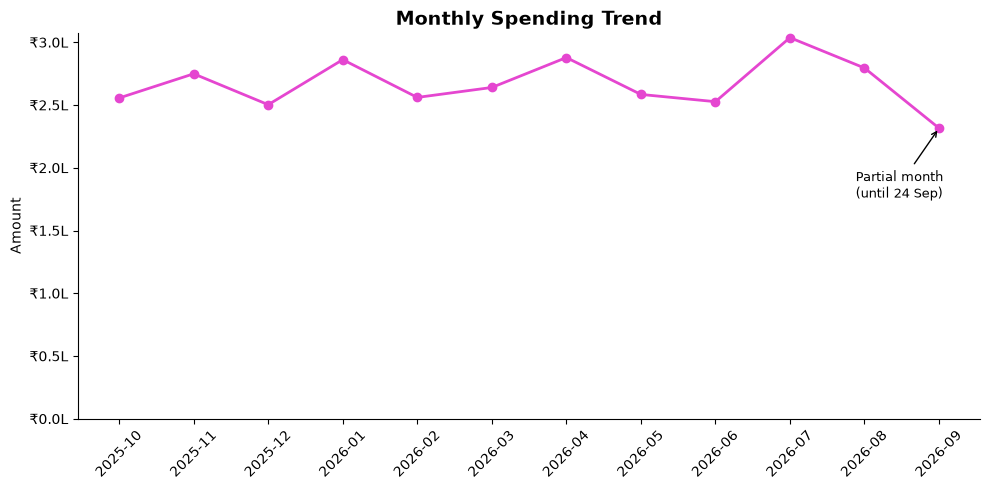

In [11]:
df["date"] = pd.to_datetime(df["date"])
monthly = df.groupby(df["date"].dt.to_period("M"))["amount"].sum()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly.index.astype(str), monthly.values, marker="o", color="#E546D0", linewidth=2)

ax.yaxis.set_major_formatter(lambda x, pos: f"₹{x/100000:.1f}L")
ax.set_title("Monthly Spending Trend", fontsize=14, fontweight="bold")
ax.set_ylabel("Amount")
ax.tick_params(axis="x", rotation=45)
ax.spines[["top", "right"]].set_visible(False)

ax.set_ylim(bottom=0)
ax.annotate("Partial month\n(until 24 Sep)", xy=(len(monthly) - 1, monthly.values[-1]),
            xytext=(-60, -50), textcoords="offset points",
            arrowprops=dict(arrowstyle="->"), fontsize=9)

plt.tight_layout()
plt.savefig("../images/monthly_trend.png", dpi=150)
plt.show()